# 02 Modelling: Trader Cohorts + Win-Probability Classifier

Two ML models on the joined dataset:

1. KMeans clustering on per-trader feature vectors to identify trader cohorts.
2. XGBoost classifier predicting the probability that a given close event is a winning trade, conditional on regime, side, size, time of day, trader cohort, and the trader's running win rate.

Both models are persisted as .pkl artefacts under ../models/ for the backtest notebook and the Streamlit dashboard to load.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_trades, load_sentiment
from src.features import attach_sentiment, add_trade_features, build_trader_features, REGIME_ORDER
from src.models import (
    fit_cohorts, describe_cohorts, save_cohorts,
    build_winprob_dataset, time_split, fit_winprob, evaluate_winprob, save_winprob,
    DEFAULT_SEED,
)

sns.set_theme(style='whitegrid', context='talk')

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
FIG_DIR = ROOT / 'outputs' / 'figures'
TBL_DIR = ROOT / 'outputs' / 'tables'
MODELS_DIR = ROOT / 'models'
for d in (FIG_DIR, TBL_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print('ready')


ready


## Load + join

In [2]:
trades = load_trades()
sent = load_sentiment()
df = attach_sentiment(trades, sent)
df = add_trade_features(df)
print('shape:', df.shape)


shape: (211224, 30)


## Trader features + cohort clustering

In [3]:
trader_feats = build_trader_features(df, min_trades=200)
print('active traders (>= 200 trades):', len(trader_feats))
trader_feats.head(3)


active traders (>= 200 trades):

 32


,trades,mean_pnl,win_rate,mean_notional,active_days,long_share,trade_freq,profit_factor,wr_Extreme Fear,wr_Fear,wr_Neutral,wr_Greed,wr_Extreme Greed
account,,,,,,,,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,419.127768,0.359612,16159.576734,24,0.448140,159.083333,4.708739,1.000000,0.890580,1.000000,0.601307,0.256098
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,6.577654,0.442720,1653.226327,52,0.419643,140.000000,2.110681,0.822581,0.797710,0.659898,0.711191,1.000000
0x271b280974205ca63b716753467d5a371de622ab,3809,-18.492043,0.301917,8893.000898,12,0.411132,317.416667,0.471902,0.980392,0.944444,0.000000,0.431373,1.000000


In [4]:
fit = fit_cohorts(trader_feats, seed=DEFAULT_SEED)
print(f'k = {fit.k},  silhouette = {fit.silhouette:.3f}')
print('cohort sizes:')
print(fit.labels.value_counts().sort_index().to_dict())
save_cohorts(fit, MODELS_DIR / 'cohort_kmeans.pkl', MODELS_DIR / 'cohort_labels.csv')


k = 7,  silhouette = 0.110
cohort sizes:
{0: 2, 1: 7, 2: 3, 3: 1, 4: 6, 5: 11, 6: 2}


In [5]:
desc = describe_cohorts(trader_feats, fit.labels)
desc.to_csv(TBL_DIR / 'cohort_description.csv')
desc.round(3)


,trades_mean,n,mean_pnl_mean,win_rate_mean,mean_notional_mean,active_days_mean,long_share_mean,trade_freq_mean,profit_factor_mean,wr_Extreme Fear_mean,wr_Fear_mean,wr_Neutral_mean,wr_Greed_mean,wr_Extreme Greed_mean
cohort,,,,,,,,,,,,,,
0,2321.000,2,155.755,0.316,5409.178,18.500,0.533,126.620,53.723,1.000,0.160,0.000,0.833,0.500
1,2422.143,7,87.189,0.402,3901.152,41.714,0.417,83.751,2.889,0.575,0.804,0.252,0.844,0.915
2,6964.000,3,164.153,0.400,24353.571,32.667,0.486,203.685,3.951,0.769,0.889,0.826,0.505,0.085
3,21192.000,1,44.364,0.468,3210.473,28.000,0.528,756.857,100.000,1.000,0.986,1.000,0.333,0.000
4,3392.333,6,88.032,0.529,3794.239,62.333,0.446,47.062,30.635,0.986,0.881,0.927,0.950,0.901
5,11415.364,11,25.589,0.353,4318.500,133.091,0.514,95.400,7.674,0.628,0.877,0.867,0.834,0.783
6,810.000,2,428.819,0.360,3793.596,24.000,0.254,31.664,0.000,0.500,1.000,1.000,1.000,1.000


## Win-probability classifier

In [6]:
closes = df[df['closed_pnl'] != 0].dropna(subset=['regime']).copy()
print('close events:', len(closes))

ds = build_winprob_dataset(closes, fit.labels)
train, test = time_split(ds, frac=0.8)
print('train:', len(train), 'test:', len(test))
print('class balance (train):', train['__label__'].mean().round(3), 'win rate')

model = fit_winprob(train, seed=DEFAULT_SEED)
res = evaluate_winprob(model, test)
print(f'\noverall AUC = {res["overall_auc"]:.4f}')
print('\nper-regime AUC:')
print(res['per_regime'].round(4).to_string(index=False))

# persist
save_winprob(model, MODELS_DIR / 'winprob_xgb.pkl')

# eval table
eval_tbl = pd.DataFrame([{'slice': 'overall', 'n': len(test), 'auc': res['overall_auc']}])
eval_tbl = pd.concat([eval_tbl, res['per_regime']], ignore_index=True)
eval_tbl.to_csv(TBL_DIR / 'model_eval.csv', index=False)
eval_tbl.round(4)


close events: 104402


train: 83521 test: 20881
class balance (train): 0.855 win rate



overall AUC = 0.5786

per-regime AUC:
              slice    n    auc
regime_Extreme Fear  919 0.8122
        regime_Fear 8579 0.4575
     regime_Neutral 3250 0.5624
       regime_Greed 8133 0.5432


,slice,n,auc
0,overall,20881,0.5786
1,regime_Extreme Fear,919,0.8122
2,regime_Fear,8579,0.4575
3,regime_Neutral,3250,0.5624
4,regime_Greed,8133,0.5432


## Calibration plot

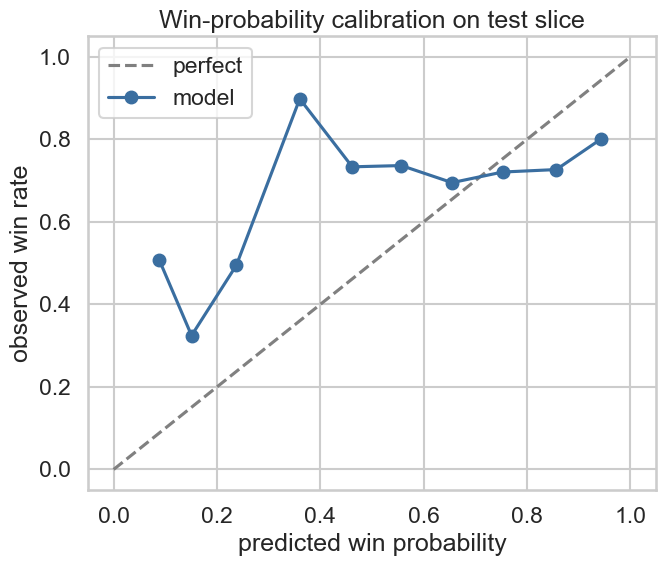

In [7]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(res['y_true'], res['proba'], n_bins=10)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'--', color='grey', label='perfect')
ax.plot(prob_pred, prob_true, marker='o', color='#3a6ea0', label='model')
ax.set_xlabel('predicted win probability')
ax.set_ylabel('observed win rate')
ax.set_title('Win-probability calibration on test slice')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'winprob_calibration.png', dpi=140)
plt.show()
plt.close('all')


## Feature importance

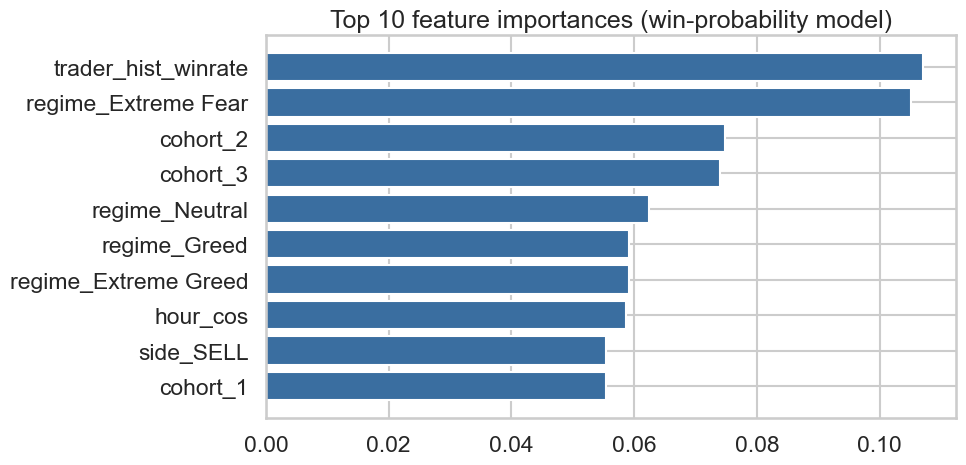

,feature,importance
0,trader_hist_winrate,0.107091
1,regime_Extreme Fear,0.105121
2,cohort_2,0.074758
3,cohort_3,0.073979
4,regime_Neutral,0.062394
5,regime_Greed,0.059203
6,regime_Extreme Greed,0.059172
7,hour_cos,0.058609
8,side_SELL,0.055482
9,cohort_1,0.055351


In [8]:
drop = {'__ts__','__label__','__account__'}
feat_cols = [c for c in test.columns if c not in drop]
importances = model.feature_importances_
order = np.argsort(importances)[::-1][:10]
imp_df = pd.DataFrame({'feature':[feat_cols[i] for i in order], 'importance':importances[order]})

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#3a6ea0')
ax.set_title('Top 10 feature importances (win-probability model)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'winprob_feature_importance.png', dpi=140)
plt.show()
plt.close('all')
imp_df
